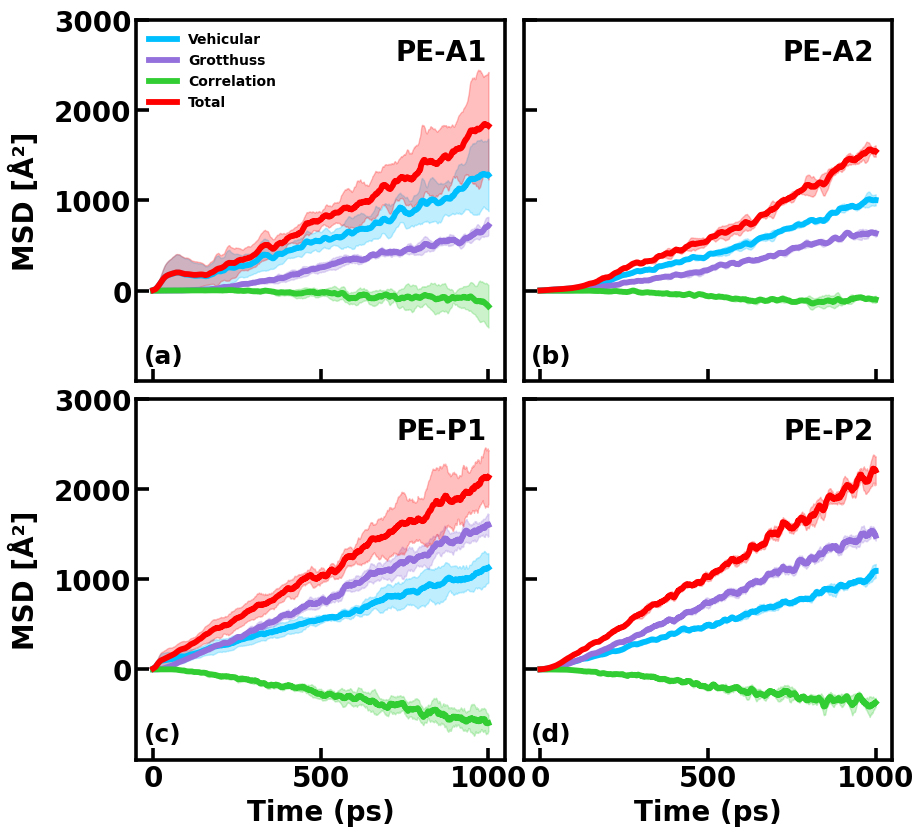

Saved: AllSystems_type10_ACS_panels.png
Saved: AllSystems_type10_ACS_panels.pdf


In [ ]:
#!/usr/bin/env python3

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt



# -----------------------------
# USER SETTINGS
# -----------------------------
DT_FS = 1.0

FILES = {
    "A1": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/MSD_Analysis/A1_type10_replica_average_meanStd.csv",
    "A2": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A2/MSD_Analysis/A2_type9_replica_average_meanStd.csv",
    "P1": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P1/MSD_Analysis/P1_type10_replica_average_meanStd.csv",
    "P2": "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P2/MSD_Analysis/P2_type9_replica_average_meanStd.csv",
}

OUT_PNG = "AllSystems_type10_ACS_panels.png"
OUT_PDF = "AllSystems_type10_ACS_panels.pdf"

# -----------------------------
# PLOT STYLE
# -----------------------------
LINE_W = 4.2
ALPHA = 0.25
AX_W = 2.6
TICK_W = 2.6
TICK_LEN = 9
SMOOTH = 15

COL_CONT  = "deepskyblue"
COL_DISC  = "mediumpurple"
COL_CORR  = "limegreen"
COL_TOTAL = "red"

YMIN = -1000
YMAX = 3000
XMIN = -50
XMAX = 1050

LABEL_SIZE = 20
TICK_SIZE = 20
TITLE_SIZE = 20
PANEL_SIZE = 18
LEGEND_SIZE = 16

# -----------------------------
# GLOBAL STYLE
# -----------------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": AX_W,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# -----------------------------
# FUNCTIONS
# -----------------------------
def smooth(y, w):
    if w <= 1:
        return y
    return pd.Series(y).rolling(
        window=w,
        center=True,
        min_periods=max(2, w // 3)
    ).mean().to_numpy()

def load_csv(path):
    df = pd.read_csv(path)
    return pd.DataFrame({
        "time": df["time"],
        "cont_mean": df["cont_sq_mean"],
        "cont_std": df["cont_sq_std"],
        "disc_mean": df["disc_sq_mean"],
        "disc_std": df["disc_sq_std"],
        "corr_mean": df["corr_mean"],
        "corr_std": df["corr_sq_std"] if "corr_sq_std" in df else df["corr_std"],
        "tot_mean": df["total_mean"],
        "tot_std": df["total_std"]
    })


def style_ticklabels(ax):

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=TICK_SIZE,
        width=TICK_W,
        length=TICK_LEN,
        top=False,
        right=False
    )

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")


def plot_panel(ax, df, title, panel_label, xlabel=False, ylabel=False, legend=False):

    x = df["time"].values * DT_FS * 0.001  # fs → ps

    def draw(mean, std, color, label):
        m = smooth(mean, SMOOTH)
        s = smooth(std, SMOOTH)

        ax.plot(x, m, lw=LINE_W, color=color, label=label)
        ax.fill_between(x, m - s, m + s, color=color, alpha=ALPHA)

    draw(df["cont_mean"], df["cont_std"], COL_CONT, "Vehicular")
    draw(df["disc_mean"], df["disc_std"], COL_DISC, "Grotthuss")
    draw(df["corr_mean"], df["corr_std"], COL_CORR, "Correlation")
    draw(df["tot_mean"], df["tot_std"], COL_TOTAL, "Total")

    # axis limits
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)

    # FEWER TICKS
    ax.set_xticks([0, 500, 1000])
    ax.set_yticks([0, 1000, 2000, 3000])

    ax.minorticks_off()

    style_ticklabels(ax)

    if xlabel:
        ax.set_xlabel("Time (ps)", fontsize=LABEL_SIZE)

    if ylabel:
        ax.set_ylabel("MSD [Å²]", fontsize=LABEL_SIZE, labelpad=10)

    # system title
    ax.text(
        0.95, 0.95,
        title,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=TITLE_SIZE,
        fontweight="bold"
    )

    # panel label
    ax.text(
        0.02, 0.05,
        panel_label,
        transform=ax.transAxes,
        fontsize=PANEL_SIZE,
        fontweight="bold"
    )

    if legend:
        ax.legend(
            loc="upper left",
            frameon=False,
            fontsize=LEGEND_SIZE,
            prop={"weight": "bold"}
        )


# -----------------------------
# MAIN
# -----------------------------
data = {k: load_csv(v) for k, v in FILES.items()}

fig, axes = plt.subplots(
    2, 2,
    figsize=(9, 8.5),
    sharex=True,
    sharey=True
)

plot_panel(axes[0,0], data["A1"], "PE-A1", "(a)", xlabel=False, ylabel=True, legend=True)
plot_panel(axes[0,1], data["A2"], "PE-A2", "(b)", xlabel=False, ylabel=False)
plot_panel(axes[1,0], data["P1"], "PE-P1", "(c)", xlabel=True, ylabel=True)
plot_panel(axes[1,1], data["P2"], "PE-P2", "(d)", xlabel=True, ylabel=False)

# top row: hide x tick labels
axes[0,0].tick_params(labelbottom=False)
axes[0,1].tick_params(labelbottom=False)

# right column: hide y tick labels
axes[0,1].tick_params(labelleft=False)
axes[1,1].tick_params(labelleft=False)

# panel spacing
fig.subplots_adjust(
    left=0.14,
    right=0.98,
    bottom=0.11,
    top=0.98,
    wspace=0.05,
    hspace=0.05
)

plt.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
plt.savefig(OUT_PDF, dpi=600, bbox_inches="tight")

plt.show()

print("Saved:", OUT_PNG)
print("Saved:", OUT_PDF)